<a href="https://colab.research.google.com/github/crwendler7-lab/Data-Science-II/blob/main/TrabajoCDII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Carga del Dataset**

In [28]:
url='https://raw.githubusercontent.com/crwendler7-lab/Data-Science-II/refs/heads/main/ai_student_impact_dataset%20(1).csv'
df=pd.read_csv(url)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


Visualización de las dimenciones del dataset

In [29]:
df.shape

(50000, 16)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [31]:
print(df.isnull().sum())

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


In [32]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000



Renombrar las columnas

In [73]:
df=df.rename(columns={
    "Student_ID":"ID_estudiante",
    "Major_Category":"Categoria_Principal",
    "Year_of_Study":"Año_de_estudio",
    "Pre_Semester_GPA":"Promedio_de_calificaciones",
    "Weekly_GenAI_Hours":"Horas_semanales_con_IA",
    "Primary_Use_Case":"Caso_de_uso_primario",
    "Prompt_Engineering_Skill":"Habilidad_prompt",
    "Tool_Diversity":"diversidad_de_herramientas",
    "Paid_Subscription":"Suscripcion",
    "Traditional_Study_Hours":"Horas_de_estudio_sin_IA",
    "Perceived_AI_Dependency":"Dependencia_de_IA",
    "Institutional_Policy":"Politica_institucional",
    "Anxiety_Level_During_Exams":"Ansiedad",
    "Post_Semester_GPA":"Puntuacion_post_semestre",
    "Skill_Retention_Score":"Nivel_de_retencion",
    "Burnout_Risk_Level":"Nivel_Burnout"
})
df.head()

,ID_estudiante,Categoria_Principal,Año_de_estudio,Promedio_de_calificaciones,Horas_semanales_con _IA,Caso_de_uso_primario,Habilidad_prompt,diversidad_de_herramientas,Suscripcion,Horas_de_estudio_sin_IA,Dependencia_de_IA,Politica_institucional,Anciedad,Puntuacion_post_semestre,Nivel_de_retencion,Nivel_Burnout,GPA_Change,Cambio_de_calificacion
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0.163


Identificar valores nulos

In [65]:
df.isnull().sum()

,0
ID_estudiante,0
Categoria_Principal,0
Año_de_estudio,0
Promedio_de_calificaciones,0
Horas_semanales_con _IA,0
Caso_de_uso_primario,0
Habilidad_prompt,0
diversidad_de_herramientas,0
Suscripcion,0
Horas_de_estudio_sin_IA,0


0 como valor nulo

In [66]:
zero=df==0
zero.sum()

,0
ID_estudiante,0
Categoria_Principal,0
Año_de_estudio,0
Promedio_de_calificaciones,0
Horas_semanales_con _IA,28
Caso_de_uso_primario,0
Habilidad_prompt,0
diversidad_de_herramientas,0
Suscripcion,28846
Horas_de_estudio_sin_IA,0


Indentificación de duplicados

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df['Cambio_de_calificacion']=df['Puntuacion_post_semestre']-df['Promedio_de_calificaciones']
df.head()

,ID_estudiante,Categoria_Principal,Año_de_estudio,Promedio_de_calificaciones,Horas_semanales_con _IA,Caso_de_uso_primario,Habilidad_prompt,diversidad_de_herramientas,Suscripcion,Horas_de_estudio_sin_IA,Dependencia_de_IA,Politica_institucional,Anciedad,Puntuacion_post_semestre,Nivel_de_retencion,Nivel_Burnout,GPA_Change,Cambio_de_calificacion
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0.163


<Figure size 1000x600 with 0 Axes>

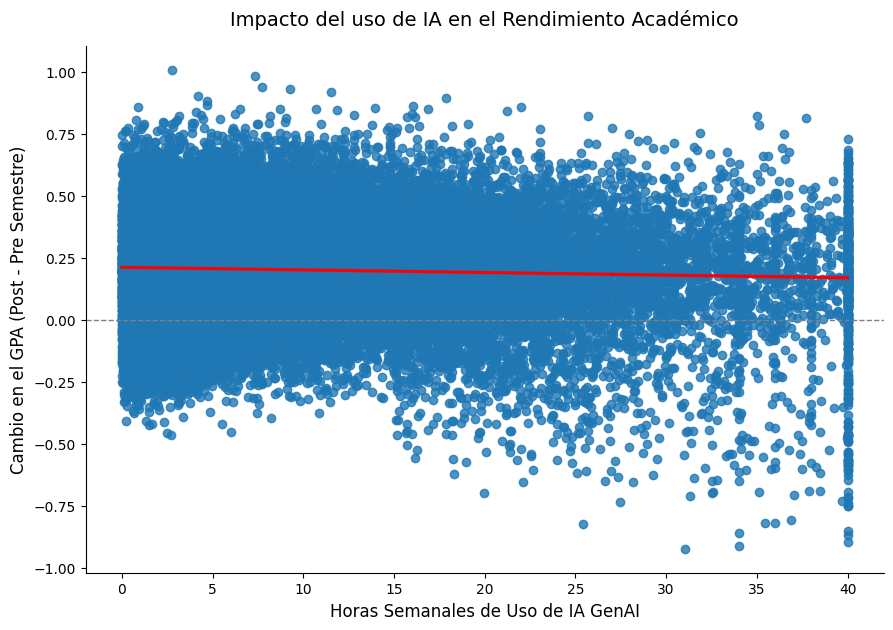

In [74]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df,
    x='Horas_semanales_con _IA',
    y='Cambio_de_calificacion',
    height=6,
    aspect=1.5,
    line_kws={'color': 'red'}
)
plt.title('Impacto del uso de IA en el Rendimiento Académico', fontsize=14, pad=15)
plt.xlabel('Horas Semanales de Uso de IA GenAI', fontsize=12)
plt.ylabel('Cambio en el GPA (Post - Pre Semestre)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.show()